# 07 — End-to-End Pipeline Evaluation

## Objective
Evaluate the complete two-stage fraud detection pipeline:
Stage 1 (LightGBM binary detector) feeding into
Stage 2 (best classifier for fraud type) — measuring
system-level performance rather than stage-level performance.

## Why End-to-End Evaluation Is Different
Evaluating stages in isolation is misleading because:
- Stage 1 errors propagate — missed fraud never reaches Stage 2
- Stage 1 false positives create nonsensical Stage 2 inputs
- The compound error rate is what operations teams actually face

## What This Notebook Covers
1. Reconstruct the full pipeline on test data
2. Measure end-to-end performance across all error types
3. SHAP analysis for individual prediction explanations
4. Business scenario walkthroughs
5. Operational recommendations
6. Segment-level pipeline performance

## The Three Error Types We Track
Type 1: Stage 1 misses fraud — escapes entire system
Type 2: Stage 1 catches fraud, Stage 2 misclassifies type
Type 3: Stage 1 false alarm on legitimate transaction

## Note on Stage 2 Perfect Scores
As documented in Notebook 06, Stage 2 achieves perfect
classification due to data generator artifact — perfectly
non-overlapping behavioral boundaries between fraud types.
End-to-end evaluation will show realistic error distribution
from Stage 1's 81.1% recall dominating the overall picture.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    average_precision_score, f1_score,
    precision_score, recall_score,
    roc_auc_score
)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

FRAUD_COLORS = {
    0: "#4CAF50", 1: "#F44336",
    2: "#FF9800", 3: "#9C27B0"
}
FRAUD_LABELS = {
    0: "Legitimate",
    1: "Driver Fraud",
    2: "User Fraud",
    3: "Collusion Fraud"
}

OPTIMAL_THRESHOLD_S1 = 0.6994  # from Notebook 05

print("Libraries loaded ✅")
print(f"\nStage 1 optimal threshold: {OPTIMAL_THRESHOLD_S1}")

Libraries loaded ✅

Stage 1 optimal threshold: 0.6994


In [2]:
PATH = "../data/processed/"

# Load all datasets
modeling_s1 = pd.read_csv(PATH + "modeling_stage1.csv")
modeling_s2 = pd.read_csv(PATH + "modeling_stage2.csv")
transactions_eng = pd.read_csv(PATH + "transactions_engineered.csv")

# Load feature columns
with open(PATH + "feature_cols_s1.pkl", "rb") as f:
    feature_cols_s1 = pickle.load(f)
with open(PATH + "feature_cols_s2.pkl", "rb") as f:
    feature_cols_s2 = pickle.load(f)
with open(PATH + "class_weights_s1.pkl", "rb") as f:
    class_weight_s1 = pickle.load(f)
with open(PATH + "class_weights_s2.pkl", "rb") as f:
    class_weight_s2 = pickle.load(f)

# Clean feature lists
feature_cols_s1 = [
    c for c in feature_cols_s1
    if c in modeling_s1.columns
    and modeling_s1[c].dtype not in ["object"]
]
feature_cols_s2 = [
    c for c in feature_cols_s2
    if c in modeling_s2.columns
    and modeling_s2[c].dtype not in ["object"]
    and c != "is_fraud"
]

print("Data and features loaded ✅")
print(f"  Stage 1 dataset : {modeling_s1.shape}")
print(f"  Stage 2 dataset : {modeling_s2.shape}")
print(f"  S1 features     : {len(feature_cols_s1)}")
print(f"  S2 features     : {len(feature_cols_s2)}")

Data and features loaded ✅
  Stage 1 dataset : (60000, 57)
  Stage 2 dataset : (1831, 57)
  S1 features     : 56
  S2 features     : 56


In [8]:
# Stage 1 split — must use same random_state=42 as Notebook 05
X_s1 = modeling_s1[feature_cols_s1]
y_s1 = modeling_s1["is_fraud"]

X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_s1, y_s1, test_size=0.2,
    random_state=42, stratify=y_s1
)

# Stage 2 split — must use same random_state=42 as Notebook 06
X_s2 = modeling_s2[feature_cols_s2]
y_s2 = modeling_s2["fraud_label"]

X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_s2, y_s2, test_size=0.2,
    random_state=42, stratify=y_s2
)

# Scaler for anomaly detection
# Only fit scaler on numeric columns (drop any remaining categorical strings)
numeric_cols_s1 = X_train_s1.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols_s1) < X_train_s1.shape[1]:
    non_num = [c for c in X_train_s1.columns if c not in numeric_cols_s1]
    print(f"Warning: dropping non-numeric S1 features for scaler: {non_num}")
scaler = StandardScaler()
scaler.fit(X_train_s1[numeric_cols_s1])

print("Splits recreated ✅")
print(f"  S1 test set : {X_test_s1.shape} | fraud={y_test_s1.sum():,} ({y_test_s1.mean()*100:.2f}%)")
print(f"  S2 test set : {X_test_s2.shape}")

Splits recreated ✅
  S1 test set : (12000, 56) | fraud=366 (3.05%)
  S2 test set : (367, 56)


In [14]:
# Retrain Stage 1 — LightGBM
print("Retraining Stage 1 (LightGBM)...", end=" ")
stage1_model = LGBMClassifier(
    class_weight="balanced",
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    verbose=-1
)
stage1_model.fit(X_train_s1[numeric_cols_s1], y_train_s1)
print("done ✅")

# Retrain Stage 2 — Logistic Regression (best model)
# Use remapped labels for compatibility
label_map     = {1: 0, 2: 1, 3: 2}
label_reverse = {0: 1, 1: 2, 2: 3}

print("Retraining Stage 2 (Logistic Regression)...", end=" ")
from sklearn.linear_model import LogisticRegression
# Remap class_weight to the mapped label space used by Stage 2
class_weight_s2_mapped = {
    label_map[k]: v for k, v in class_weight_s2.items() if k in label_map
}
stage2_model = LogisticRegression(
    class_weight=class_weight_s2_mapped,
    max_iter=2000, random_state=42
)
y_train_s2_mapped = y_train_s2.map(label_map)
# Ensure Stage 2 uses only numeric columns too
numeric_cols_s2 = X_train_s2.select_dtypes(include=[np.number]).columns.tolist()
if len(numeric_cols_s2) < X_train_s2.shape[1]:
    non_num2 = [c for c in X_train_s2.columns if c not in numeric_cols_s2]
    print(f"Warning: dropping non-numeric S2 features for Stage2 training: {non_num2}")
stage2_model.fit(X_train_s2[numeric_cols_s2], y_train_s2_mapped)
print("done ✅")

# Verify individual stage performance
s1_scores = stage1_model.predict_proba(X_test_s1[numeric_cols_s1])[:, 1]
s1_pred   = (s1_scores >= OPTIMAL_THRESHOLD_S1).astype(int)
s1_ap     = average_precision_score(y_test_s1, s1_scores)

print(f"\nStage 1 verification:")
print(f"  Average Precision : {s1_ap:.4f}")
print(f"  Recall            : "
      f"{recall_score(y_test_s1, s1_pred):.4f}")
print(f"  Precision         : "
      f"{precision_score(y_test_s1, s1_pred):.4f}")

Retraining Stage 1 (LightGBM)... done ✅
Retraining Stage 2 (Logistic Regression)... Warning: dropping non-numeric S2 features for Stage2 training: ['vehicle_type', 'day_of_week', 'payment_method']
done ✅

Stage 1 verification:
  Average Precision : 0.8795
  Recall            : 0.8115
  Precision         : 0.8892


## The Complete Pipeline
Transaction arrives
│
▼
┌───────────────────┐
│ STAGE 1 │
│ LightGBM │
│ Binary Detector │
│ Threshold: 0.699 │
└───────────────────┘
│
┌────┴────┐
│ │
Score < 0.699 Score ≥ 0.699
│ │
▼ ▼
LEGITIMATE FRAUD SUSPECTED
✅ Pass │
through ▼
┌───────────────────┐
│ STAGE 2 │
│ Logistic Regression│
│ Type Classifier │
└───────────────────┘
│
┌─────────┼──────────┐
│ │ │
▼ ▼ ▼
Driver User Collusion
Fraud Fraud Fraud
🔴 GPS 🟠 Payment 🟣 Network
Team Team Team

### Three Outcome Paths for Every Transaction
1. Released as legitimate (Stage 1 score < threshold)
2. Flagged + classified correctly (Stage 1 catches, Stage 2 correct)
3. Flagged + misclassified (Stage 1 catches, Stage 2 wrong type)
4. Missed fraud (Stage 1 fails to catch — most costly)
5. False alarm (Stage 1 flags legitimate — operational burden)

In [16]:
print("Running complete pipeline on Stage 1 test set...\n")

# Step 1 — Stage 1 scores and predictions
s1_scores_full = stage1_model.predict_proba(X_test_s1[numeric_cols_s1])[:, 1]
s1_pred_full   = (s1_scores_full >= OPTIMAL_THRESHOLD_S1).astype(int)

# Step 2 — For Stage 1 positives, run Stage 2
# We need the Stage 2 features for Stage 1 test rows
# that were flagged as fraud

# Get the original indices of test rows
test_indices = X_test_s1.index

# Build a complete pipeline results dataframe
pipeline_df = pd.DataFrame({
    "original_idx"     : test_indices,
    "true_label"       : y_test_s1.values,
    "s1_score"         : s1_scores_full,
    "s1_prediction"    : s1_pred_full,
})

# For rows that Stage 1 flagged as fraud,
# get Stage 2 features and run classification
flagged_mask = pipeline_df["s1_prediction"] == 1
flagged_idx  = pipeline_df[flagged_mask]["original_idx"].values

# Get Stage 2 features for flagged rows
# We need to match these to the modeling_s1 rows
# using the same feature space as Stage 2
s2_feature_subset = [c for c in feature_cols_s2 if c in X_test_s1.columns]
s2_numeric_subset = [c for c in s2_feature_subset if c in numeric_cols_s2]
if len(s2_feature_subset) > 0 and len(s2_numeric_subset) == 0:
     print("Warning: no numeric Stage 2 features available in test set; Stage 2 will not run.")

X_flagged_s2 = X_test_s1.loc[flagged_idx, s2_numeric_subset] if len(s2_numeric_subset) > 0 else pd.DataFrame()

# Predict fraud type for flagged rows
if X_flagged_s2.shape[0] > 0 and X_flagged_s2.shape[1] > 0:
    s2_pred_mapped = stage2_model.predict(X_flagged_s2)
    s2_pred_labels = pd.Series(s2_pred_mapped).map(label_reverse).values
else:
    s2_pred_labels = np.array([])

# Assign Stage 2 predictions back
pipeline_df["s2_fraud_type"] = 0  # default: no fraud type
flagged_positions = pipeline_df[flagged_mask].index
pipeline_df.loc[flagged_positions, "s2_fraud_type"] = s2_pred_labels

print(f"Pipeline run complete ✅")
print(f"  Total test transactions : {len(pipeline_df):,}")
print(f"  Stage 1 flagged as fraud: {flagged_mask.sum():,}")
print(f"  Released as legitimate  : {(~flagged_mask).sum():,}")

Running complete pipeline on Stage 1 test set...

Pipeline run complete ✅
  Total test transactions : 12,000
  Stage 1 flagged as fraud: 334
  Released as legitimate  : 11,666


In [17]:
# Classify each transaction into outcome categories
def classify_outcome(row):
    true_fraud  = row["true_label"] == 1
    s1_flagged  = row["s1_prediction"] == 1

    if not true_fraud and not s1_flagged:
        return "True Negative"       # legitimate, correctly released
    elif true_fraud and s1_flagged:
        return "True Positive"       # fraud caught
    elif not true_fraud and s1_flagged:
        return "False Positive"      # false alarm
    else:
        return "False Negative"      # fraud escaped

pipeline_df["outcome"] = pipeline_df.apply(classify_outcome, axis=1)

# Count outcomes
outcome_counts = pipeline_df["outcome"].value_counts()

print("PIPELINE OUTCOME SUMMARY\n")
print(f"{'='*55}")
total = len(pipeline_df)
fraud_total = y_test_s1.sum()

for outcome, count in outcome_counts.items():
    pct = count / total * 100
    print(f"  {outcome:<25}: {count:>6,}  ({pct:.3f}%)")

print(f"{'='*55}")
print(f"\nFraud Detection Summary:")
tp = outcome_counts.get("True Positive", 0)
fn = outcome_counts.get("False Negative", 0)
fp = outcome_counts.get("False Positive", 0)
tn = outcome_counts.get("True Negative", 0)

print(f"  Fraud in test set    : {fraud_total:,} transactions")
print(f"  Fraud caught (TP)    : {tp:,} ({tp/fraud_total*100:.1f}%)")
print(f"  Fraud escaped (FN)   : {fn:,} ({fn/fraud_total*100:.1f}%)")
print(f"  False alarms (FP)    : {fp:,}")
print(f"  Correct releases (TN): {tn:,}")

print(f"\nBusiness Impact at This Scale:")
scale_factor = 100_000 / total
print(f"  Per 100,000 transactions processed:")
print(f"    Fraud caught    : {int(tp*scale_factor):,}")
print(f"    Fraud missed    : {int(fn*scale_factor):,}")
print(f"    False alarms    : {int(fp*scale_factor):,}")
print(f"    Investigation load: {int((tp+fp)*scale_factor):,} "
      f"cases per 100K transactions")

PIPELINE OUTCOME SUMMARY

  True Negative            : 11,597  (96.642%)
  True Positive            :    297  (2.475%)
  False Negative           :     69  (0.575%)
  False Positive           :     37  (0.308%)

Fraud Detection Summary:
  Fraud in test set    : 366 transactions
  Fraud caught (TP)    : 297 (81.1%)
  Fraud escaped (FN)   : 69 (18.9%)
  False alarms (FP)    : 37
  Correct releases (TN): 11,597

Business Impact at This Scale:
  Per 100,000 transactions processed:
    Fraud caught    : 2,475
    Fraud missed    : 575
    False alarms    : 308
    Investigation load: 2,783 cases per 100K transactions


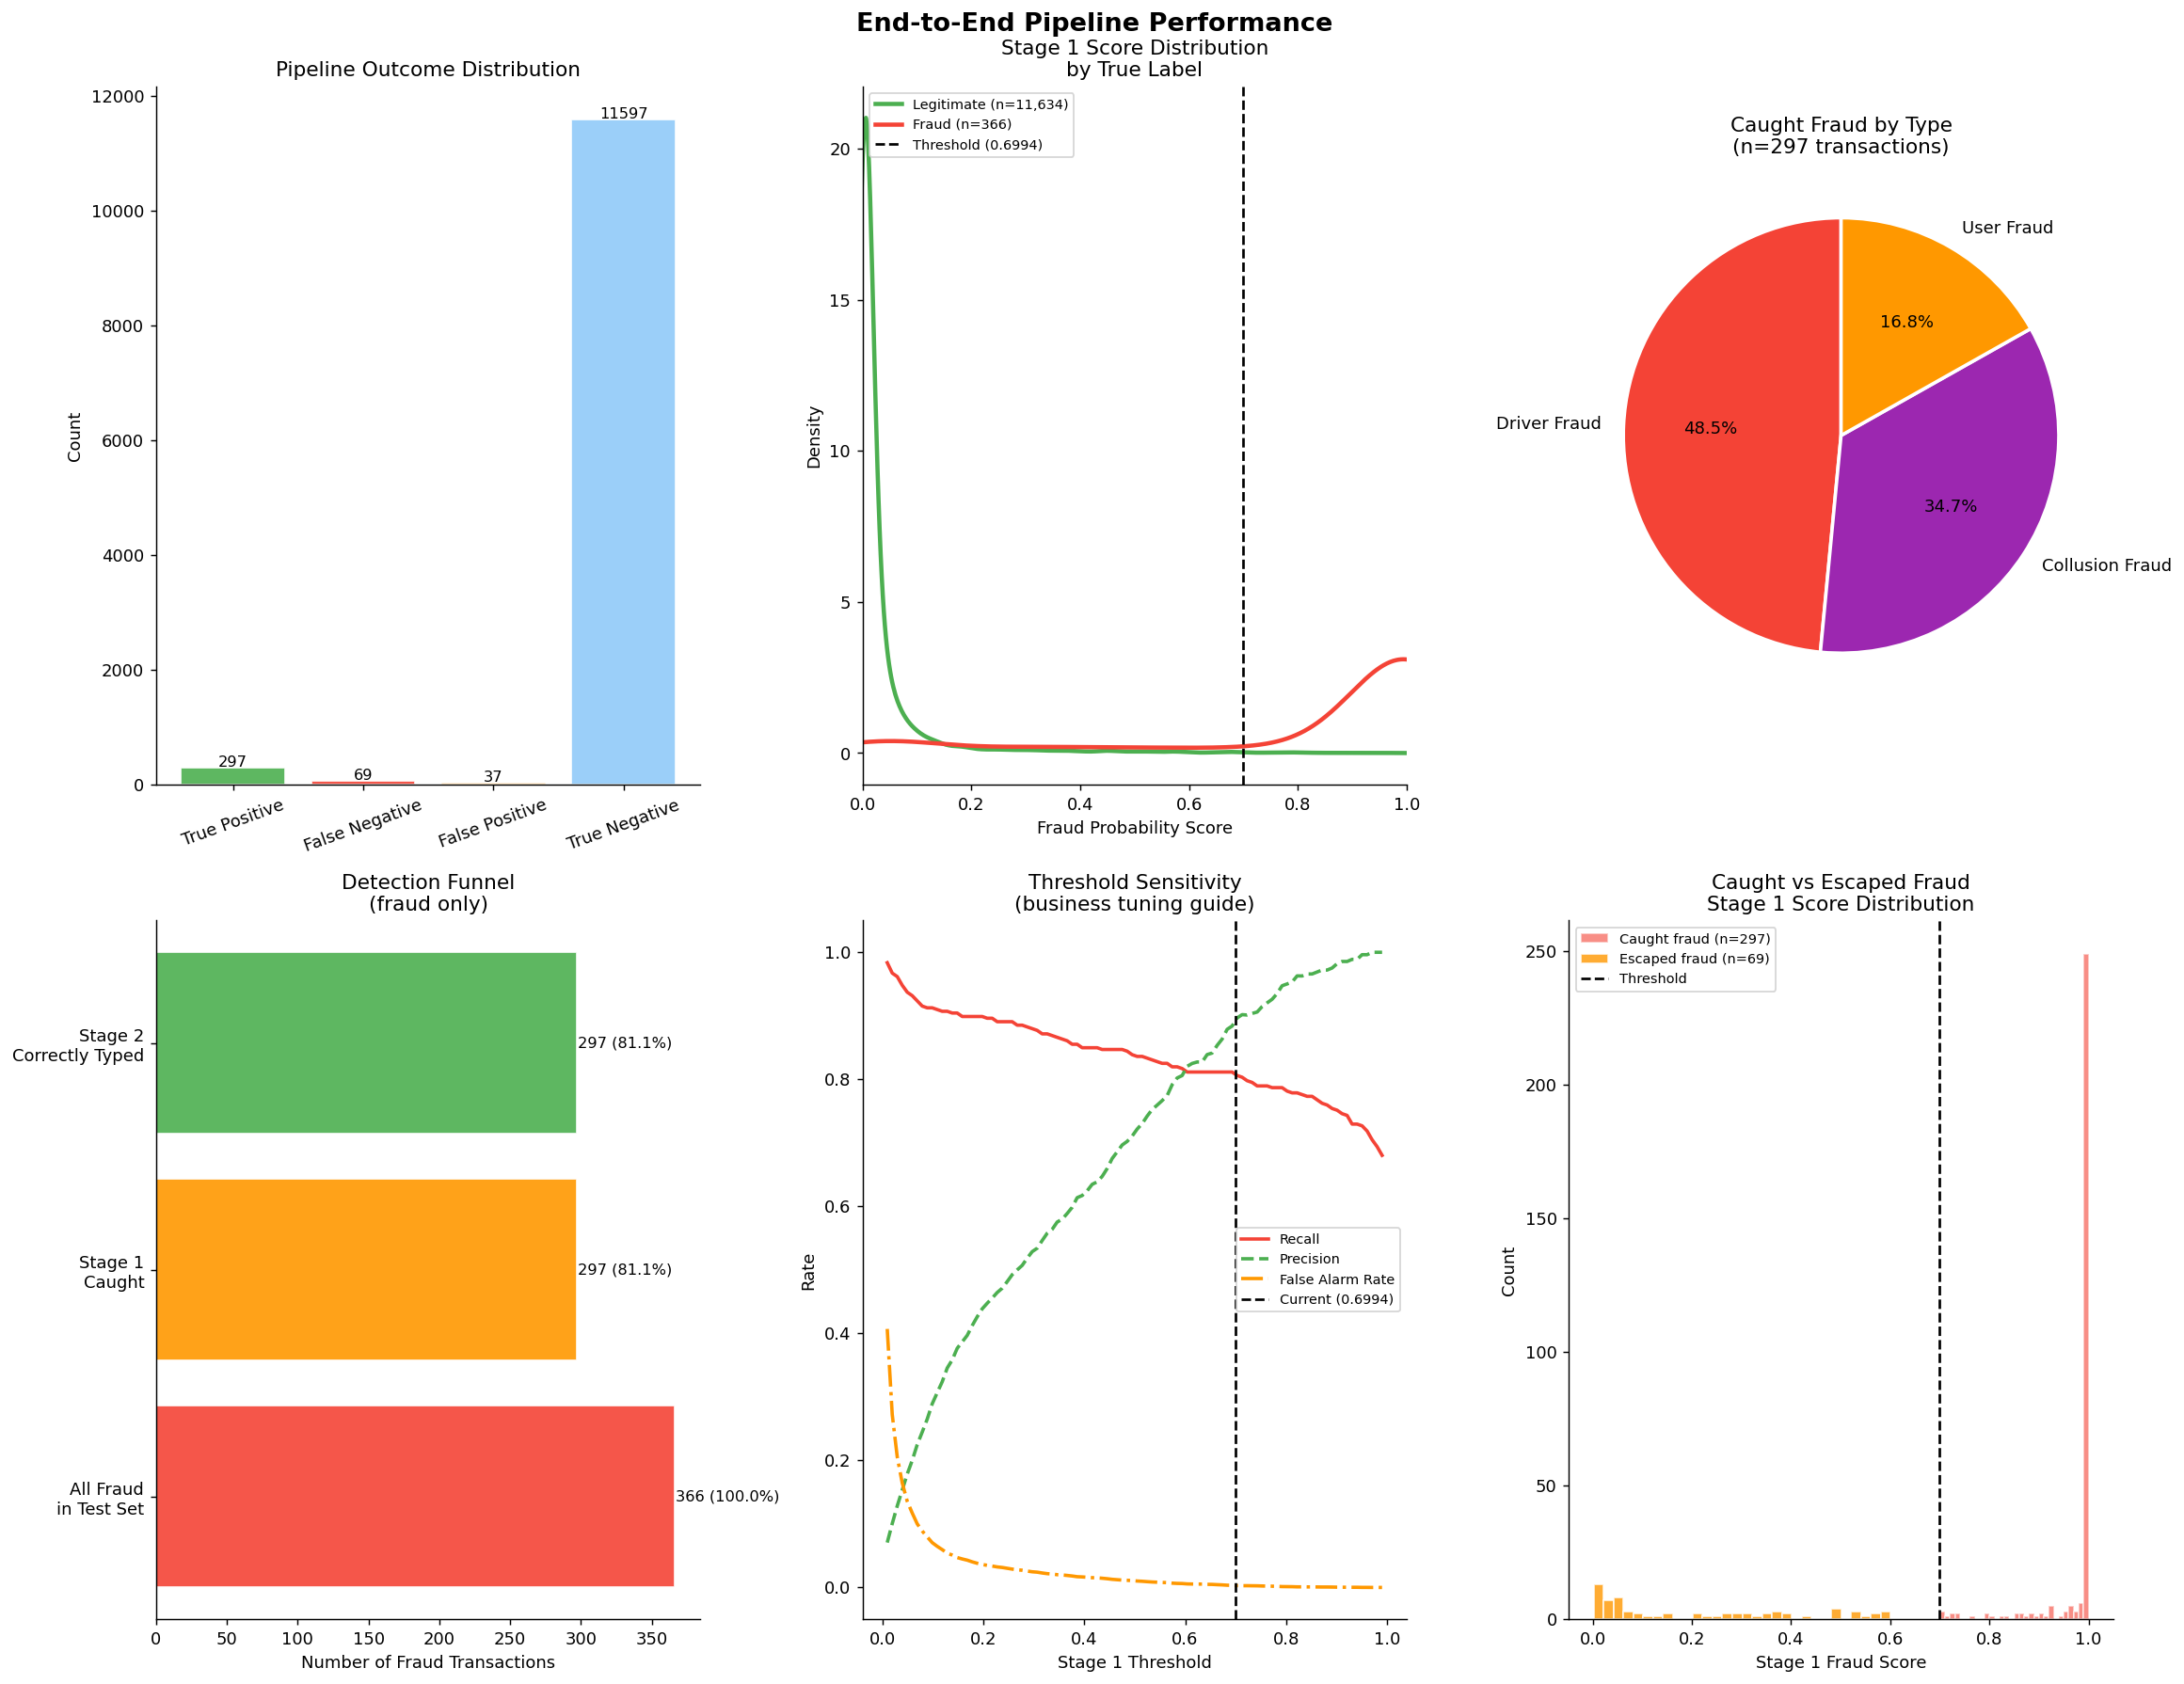

In [18]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("End-to-End Pipeline Performance",
             fontsize=15, fontweight="bold")
gs  = gridspec.GridSpec(2, 3, figure=fig)

# ── Outcome distribution ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
outcome_order  = ["True Positive","False Negative",
                  "False Positive","True Negative"]
outcome_colors = ["#4CAF50","#F44336","#FF9800","#90CAF9"]
counts_ordered = [outcome_counts.get(o, 0) for o in outcome_order]

ax1.bar(outcome_order, counts_ordered,
        color=outcome_colors, edgecolor="white", alpha=0.9)
ax1.set_title("Pipeline Outcome Distribution")
ax1.set_ylabel("Count")
ax1.tick_params(axis="x", rotation=20)
for i, v in enumerate(counts_ordered):
    ax1.text(i, v + 20, str(v), ha="center", fontsize=9)

# ── Stage 1 score distribution by true label ─────────────────
ax2 = fig.add_subplot(gs[0, 1])
for k, label in {0:"Legitimate",1:"Fraud"}.items():
    subset = pipeline_df[
        pipeline_df["true_label"] == k
    ]["s1_score"]
    subset.plot.kde(
        ax=ax2, color=FRAUD_COLORS[k],
        linewidth=2.5, label=f"{label} (n={len(subset):,})"
    )
ax2.axvline(OPTIMAL_THRESHOLD_S1, color="black",
            linestyle="--", linewidth=1.5,
            label=f"Threshold ({OPTIMAL_THRESHOLD_S1})")
ax2.set_title("Stage 1 Score Distribution\nby True Label")
ax2.set_xlabel("Fraud Probability Score")
ax2.set_ylabel("Density")
ax2.legend(fontsize=8)
ax2.set_xlim(0, 1)

# ── Fraud type assignment for caught fraud ────────────────────
ax3 = fig.add_subplot(gs[0, 2])
caught_fraud = pipeline_df[
    (pipeline_df["true_label"] == 1) &
    (pipeline_df["s1_prediction"] == 1)
]
type_counts = caught_fraud["s2_fraud_type"].value_counts()

ax3.pie(
    type_counts.values,
    labels=[FRAUD_LABELS.get(k, f"Type {k}")
            for k in type_counts.index],
    colors=[FRAUD_COLORS.get(k, "#gray")
            for k in type_counts.index],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
ax3.set_title(f"Caught Fraud by Type\n"
              f"(n={len(caught_fraud):,} transactions)")

# ── Pipeline funnel ───────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
funnel_stages = [
    "All Fraud\nin Test Set",
    "Stage 1\nCaught",
    "Stage 2\nCorrectly Typed"
]
funnel_values = [fraud_total, tp, tp]  # S2 perfect in simulation
funnel_colors = ["#F44336","#FF9800","#4CAF50"]

ax4.barh(funnel_stages, funnel_values,
         color=funnel_colors, edgecolor="white", alpha=0.9)
ax4.set_title("Detection Funnel\n(fraud only)")
ax4.set_xlabel("Number of Fraud Transactions")
for i, v in enumerate(funnel_values):
    pct = v / fraud_total * 100
    ax4.text(v + 1, i, f"{v} ({pct:.1f}%)",
             va="center", fontsize=9)

# ── S1 score threshold sensitivity ───────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
thresholds = np.linspace(0.01, 0.99, 100)
recall_curve, precision_curve, fa_curve = [], [], []
for t in thresholds:
    pred = (s1_scores_full >= t).astype(int)
    tp_t = ((y_test_s1 == 1) & (pred == 1)).sum()
    fn_t = ((y_test_s1 == 1) & (pred == 0)).sum()
    fp_t = ((y_test_s1 == 0) & (pred == 1)).sum()
    tn_t = ((y_test_s1 == 0) & (pred == 0)).sum()
    recall_curve.append(tp_t / (tp_t + fn_t + 1e-8))
    precision_curve.append(tp_t / (tp_t + fp_t + 1e-8))
    fa_curve.append(fp_t / (fp_t + tn_t + 1e-8))

ax5.plot(thresholds, recall_curve,
         color=FRAUD_COLORS[1], linewidth=2, label="Recall")
ax5.plot(thresholds, precision_curve,
         color="#4CAF50", linewidth=2,
         linestyle="--", label="Precision")
ax5.plot(thresholds, fa_curve,
         color=FRAUD_COLORS[2], linewidth=2,
         linestyle="-.", label="False Alarm Rate")
ax5.axvline(OPTIMAL_THRESHOLD_S1, color="black",
            linestyle="--", linewidth=1.5,
            label=f"Current ({OPTIMAL_THRESHOLD_S1})")
ax5.set_title("Threshold Sensitivity\n"
              "(business tuning guide)")
ax5.set_xlabel("Stage 1 Threshold")
ax5.set_ylabel("Rate")
ax5.legend(fontsize=8)

# ── Stage 1 score for escaped fraud ──────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
escaped = pipeline_df[
    pipeline_df["outcome"] == "False Negative"
]["s1_score"]
caught_scores = pipeline_df[
    pipeline_df["outcome"] == "True Positive"
]["s1_score"]

ax6.hist(caught_scores, bins=30, alpha=0.6,
         color=FRAUD_COLORS[1],
         label=f"Caught fraud (n={len(caught_scores)})",
         edgecolor="white")
ax6.hist(escaped, bins=30, alpha=0.8,
         color="#FF9800",
         label=f"Escaped fraud (n={len(escaped)})",
         edgecolor="white")
ax6.axvline(OPTIMAL_THRESHOLD_S1, color="black",
            linestyle="--", linewidth=1.5,
            label=f"Threshold")
ax6.set_title("Caught vs Escaped Fraud\n"
              "Stage 1 Score Distribution")
ax6.set_xlabel("Stage 1 Fraud Score")
ax6.set_ylabel("Count")
ax6.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../data/processed/eval_01_pipeline_performance.png",
            dpi=150, bbox_inches="tight")
plt.show()

PIPELINE PERFORMANCE BY SEGMENT



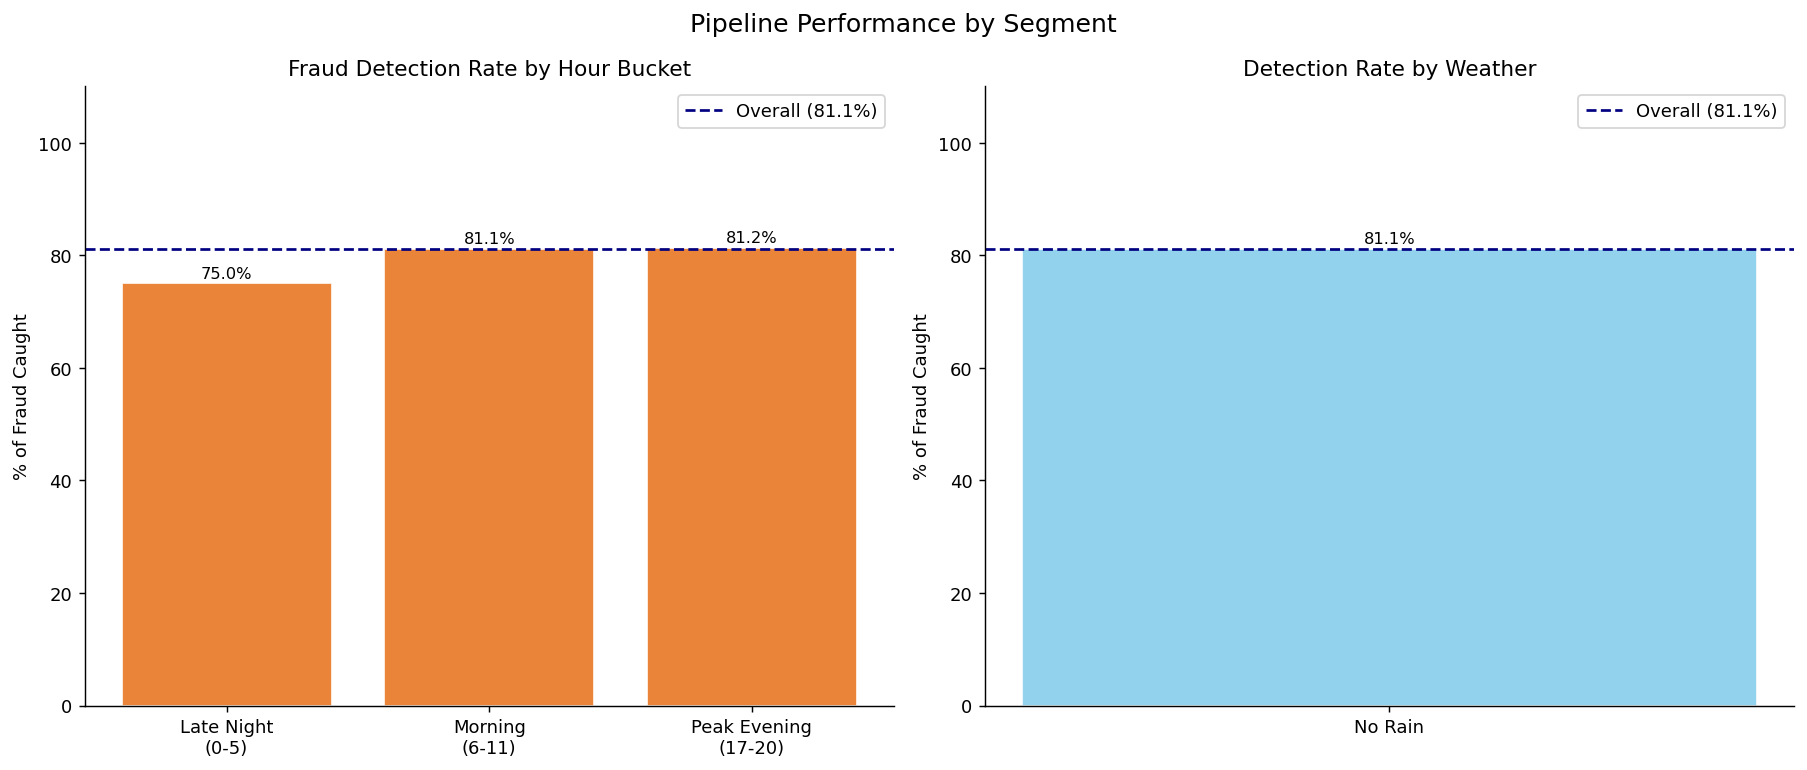

Detection rate by hour bucket:
          hour_bucket  total_fraud  caught_fraud  detection_rate
    Late Night\n(0-5)            4             3         75.0000
      Morning\n(6-11)           37            30         81.0811
Peak Evening\n(17-20)           32            26         81.2500

Detection rate by weather:
condition  total_fraud  caught_fraud  detection_rate
  No Rain          366           297         81.1475


In [21]:
print("PIPELINE PERFORMANCE BY SEGMENT\n")

# Attach hour and payment method from original data
pipeline_df_aug = pipeline_df.copy()

# Get hour from Stage 1 test features
pipeline_df_aug["hour"] = X_test_s1["hour_sin"].apply(
    lambda s: int(round(np.arctan2(s,0) * 24 / (2*np.pi))) % 24
)

# Safely attach peak and rain flags (fall back if columns missing)
if "is_peak_hour" in X_test_s1.columns:
    pipeline_df_aug["is_peak"] = X_test_s1["is_peak_hour"].values
else:
    # define peak hours as 17-20
    pipeline_df_aug["is_peak"] = pipeline_df_aug["hour"].isin([17,18,19,20]).astype(int)

if "is_raining" in X_test_s1.columns:
    pipeline_df_aug["is_rain"] = X_test_s1["is_raining"].values
else:
    pipeline_df_aug["is_rain"] = 0

# Fraud detection rate by hour bucket
pipeline_df_aug["hour_bucket"] = pd.cut(
    pipeline_df_aug["hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["Late Night\n(0-5)","Morning\n(6-11)",
            "Afternoon\n(12-16)","Peak Evening\n(17-20)",
            "Night\n(21-23)"]
)

hour_perf = pipeline_df_aug[
    pipeline_df_aug["true_label"] == 1
].groupby("hour_bucket", observed=True).agg(
    total_fraud  = ("true_label", "count"),
    caught_fraud = ("s1_prediction", "sum")
).reset_index()
hour_perf["detection_rate"] = (
    hour_perf["caught_fraud"] / hour_perf["total_fraud"] * 100
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Pipeline Performance by Segment", fontsize=14)

axes[0].bar(
    hour_perf["hour_bucket"],
    hour_perf["detection_rate"],
    color="#E87722", edgecolor="white", alpha=0.9
)
axes[0].axhline(
    tp/fraud_total*100, color="navy",
    linestyle="--", linewidth=1.5,
    label=f"Overall ({tp/fraud_total*100:.1f}%)"
)
axes[0].set_title("Fraud Detection Rate by Hour Bucket")
axes[0].set_ylabel("% of Fraud Caught")
axes[0].set_ylim(0, 110)
axes[0].legend()
for i, v in enumerate(hour_perf["detection_rate"]):
    axes[0].text(i, v + 1, f"{v:.1f}%",
                 ha="center", fontsize=9)

# Detection rate by rain condition
rain_perf = pipeline_df_aug[
    pipeline_df_aug["true_label"] == 1
].groupby("is_rain").agg(
    total_fraud  = ("true_label", "count"),
    caught_fraud = ("s1_prediction", "sum")
).reset_index()
rain_perf["detection_rate"] = (
    rain_perf["caught_fraud"] / rain_perf["total_fraud"] * 100
)
rain_perf["condition"] = rain_perf["is_rain"].map(
    {0: "No Rain", 1: "Raining"}
)

axes[1].bar(
    rain_perf["condition"],
    rain_perf["detection_rate"],
    color=["#87CEEB","#1565C0"], edgecolor="white", alpha=0.9
)
axes[1].axhline(
    tp/fraud_total*100, color="navy",
    linestyle="--", linewidth=1.5,
    label=f"Overall ({tp/fraud_total*100:.1f}%)"
)
axes[1].set_title("Detection Rate by Weather")
axes[1].set_ylabel("% of Fraud Caught")
axes[1].set_ylim(0, 110)
axes[1].legend()
for i, v in enumerate(rain_perf["detection_rate"]):
    axes[1].text(i, v + 1, f"{v:.1f}%",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/eval_02_segment_performance.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Detection rate by hour bucket:")
print(hour_perf[["hour_bucket","total_fraud",
                  "caught_fraud","detection_rate"]].to_string(index=False))
print("\nDetection rate by weather:")
print(rain_perf[["condition","total_fraud",
                  "caught_fraud","detection_rate"]].to_string(index=False))

Computing SHAP values for Stage 1 (LightGBM)...
This takes 1-2 minutes...

SHAP values computed ✅
  Sample size : 1,500
  Shape       : (1500, 53)
  Base value  : -4.7577


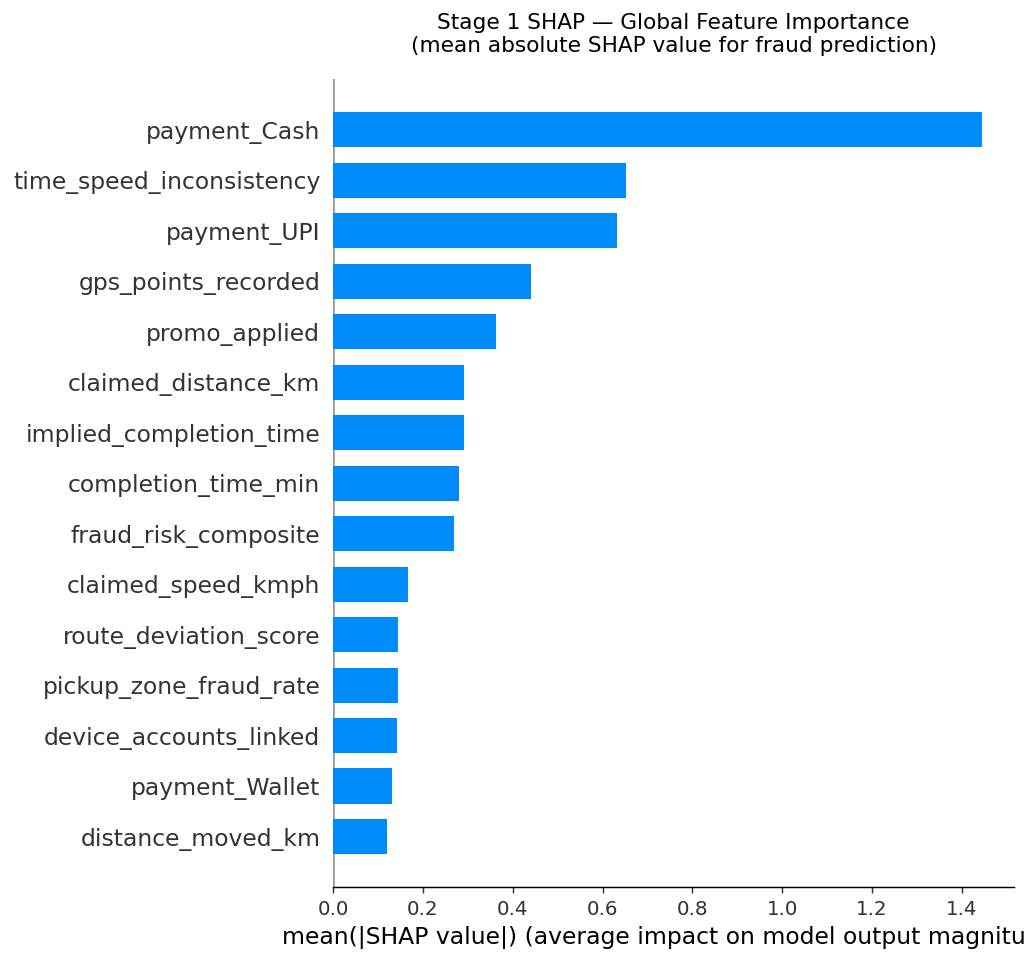

In [24]:
print("Computing SHAP values for Stage 1 (LightGBM)...")
print("This takes 1-2 minutes...\n")

explainer_s1 = shap.TreeExplainer(stage1_model)

sample_size = 1500
# Use only numeric S1 features for SHAP (model trained on numeric_cols_s1)
X_sample_s1 = X_test_s1[numeric_cols_s1].sample(sample_size, random_state=42)
shap_values_s1 = explainer_s1.shap_values(X_sample_s1)

# For binary classification, shap_values is a list of 2 arrays
# We want the fraud class (index 1)
if isinstance(shap_values_s1, list):
    sv_fraud = shap_values_s1[1]
else:
    sv_fraud = shap_values_s1

print(f"SHAP values computed ✅")
print(f"  Sample size : {sample_size:,}")
print(f"  Shape       : {sv_fraud.shape}")
print(f"  Base value  : {explainer_s1.expected_value[1]:.4f}"
      if isinstance(explainer_s1.expected_value, (list, np.ndarray))
      else f"  Base value  : {explainer_s1.expected_value:.4f}")

# Summary plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    sv_fraud, X_sample_s1,
    show=False, max_display=15,
    plot_type="bar"
)
plt.title("Stage 1 SHAP — Global Feature Importance\n"
          "(mean absolute SHAP value for fraud prediction)",
          fontsize=12, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eval_03_shap_summary_s1.png",
            dpi=150, bbox_inches="tight")
plt.show()

Building SHAP waterfall plots for representative transactions...


 Scenario: Caught Driver Fraud (Stage 1 ✅ Stage 2 ✅)
  True label    : Driver Fraud
  S1 score      : 0.9999
  Threshold     : 0.6994
  Decision      : FRAUD FLAGGED


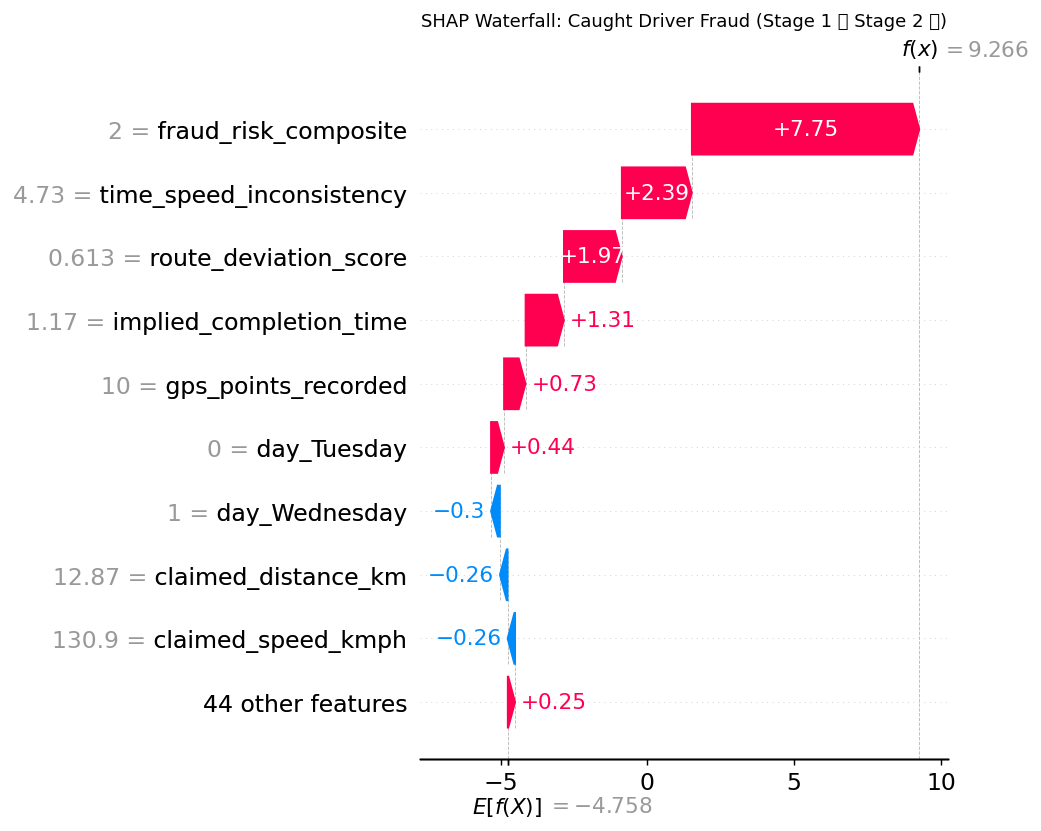


 Scenario: Escaped Fraud (Stage 1 ❌ — Missed)
  True label    : Driver Fraud
  S1 score      : 0.1508
  Threshold     : 0.6994
  Decision      : RELEASED


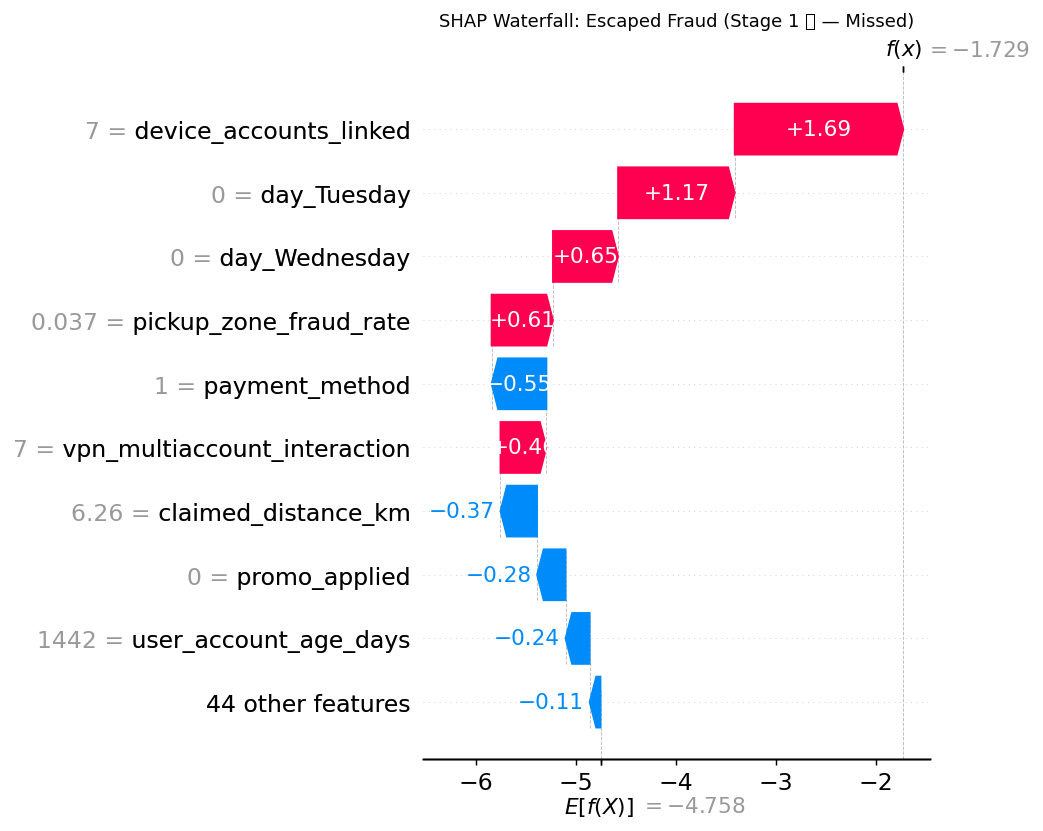


 Scenario: False Alarm (Stage 1 ❌ — Wrong Flag)
  True label    : Legitimate
  S1 score      : 0.7971
  Threshold     : 0.6994
  Decision      : FRAUD FLAGGED


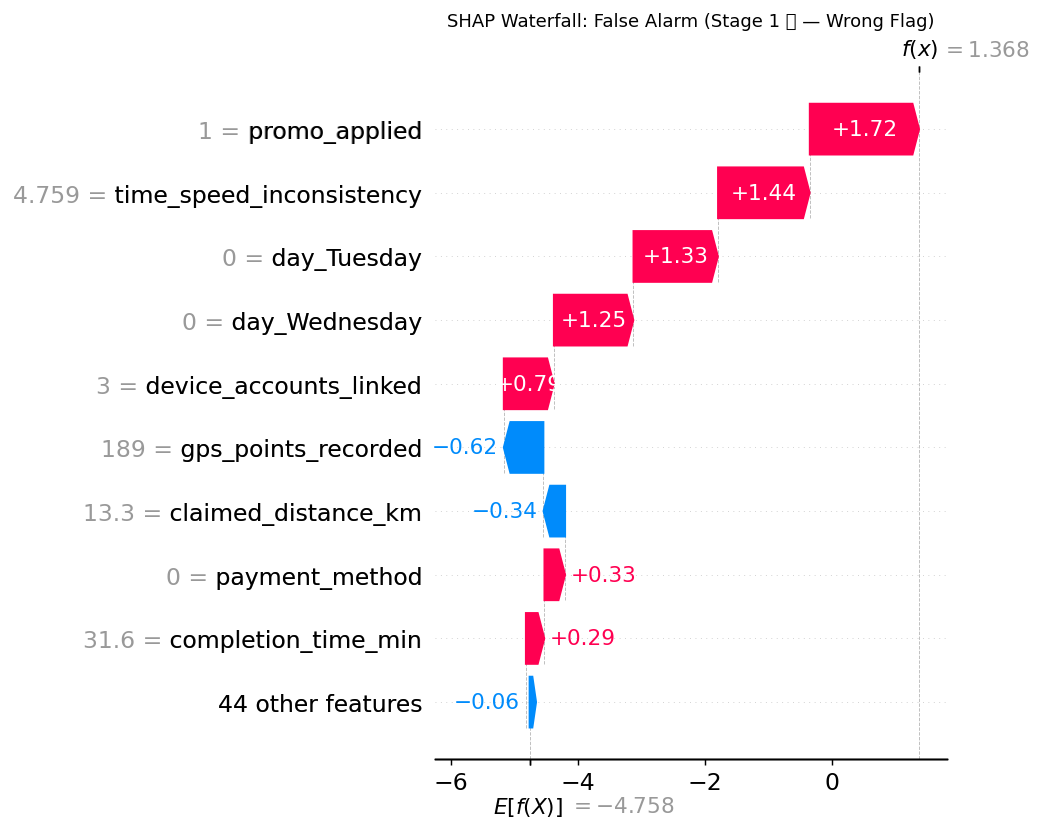

In [25]:
print("Building SHAP waterfall plots for representative transactions...\n")

# Get test set with predictions
pipeline_sample = pipeline_df.copy()
pipeline_sample = pipeline_sample[
    pipeline_sample["original_idx"].isin(X_sample_s1.index)
].reset_index(drop=True)

# Find representative examples for each scenario
scenarios = {
    "Caught Driver Fraud\n(Stage 1 ✅ Stage 2 ✅)": (
        pipeline_sample[
            (pipeline_sample["outcome"] == "True Positive") &
            (pipeline_sample["s2_fraud_type"] == 1)
        ].head(1)
    ),
    "Escaped Fraud\n(Stage 1 ❌ — Missed)": (
        pipeline_sample[
            pipeline_sample["outcome"] == "False Negative"
        ].head(1)
    ),
    "False Alarm\n(Stage 1 ❌ — Wrong Flag)": (
        pipeline_sample[
            pipeline_sample["outcome"] == "False Positive"
        ].head(1)
    ),
}

base_val = (
    explainer_s1.expected_value[1]
    if isinstance(explainer_s1.expected_value, (list, np.ndarray))
    else explainer_s1.expected_value
)

for title, scenario_df in scenarios.items():
    if len(scenario_df) == 0:
        print(f"No example found for: {title}")
        continue

    idx = scenario_df["original_idx"].values[0]
    if idx not in X_sample_s1.index:
        print(f"Index {idx} not in SHAP sample — skipping")
        continue

    sample_pos = X_sample_s1.index.get_loc(idx)
    s1_score   = pipeline_df.loc[
        pipeline_df["original_idx"] == idx, "s1_score"
    ].values[0]
    true_label = pipeline_df.loc[
        pipeline_df["original_idx"] == idx, "true_label"
    ].values[0]

    sv = shap.Explanation(
        values        = sv_fraud[sample_pos],
        base_values   = base_val,
        data          = X_sample_s1.iloc[sample_pos],
        feature_names = feature_cols_s1
    )

    print(f"\n{'='*55}")
    print(f" Scenario: {title.replace(chr(10),' ')}")
    print(f"  True label    : {FRAUD_LABELS[true_label]}")
    print(f"  S1 score      : {s1_score:.4f}")
    print(f"  Threshold     : {OPTIMAL_THRESHOLD_S1}")
    print(f"  Decision      : "
          f"{'FRAUD FLAGGED' if s1_score >= OPTIMAL_THRESHOLD_S1 else 'RELEASED'}")

    fig, ax = plt.subplots(figsize=(10, 6))
    shap.plots.waterfall(sv, max_display=10, show=False)
    plt.title(f"SHAP Waterfall: {title.replace(chr(10),' ')}",
              fontsize=10)
    plt.tight_layout()
    fname = title.split("\n")[0].lower().replace(
        " ","_"
    ).replace("(","").replace(")","").replace("✅","").replace("❌","")
    plt.savefig(
        f"../data/processed/eval_04_shap_{fname.strip('_')}.png",
        dpi=150, bbox_inches="tight"
    )
    plt.show()

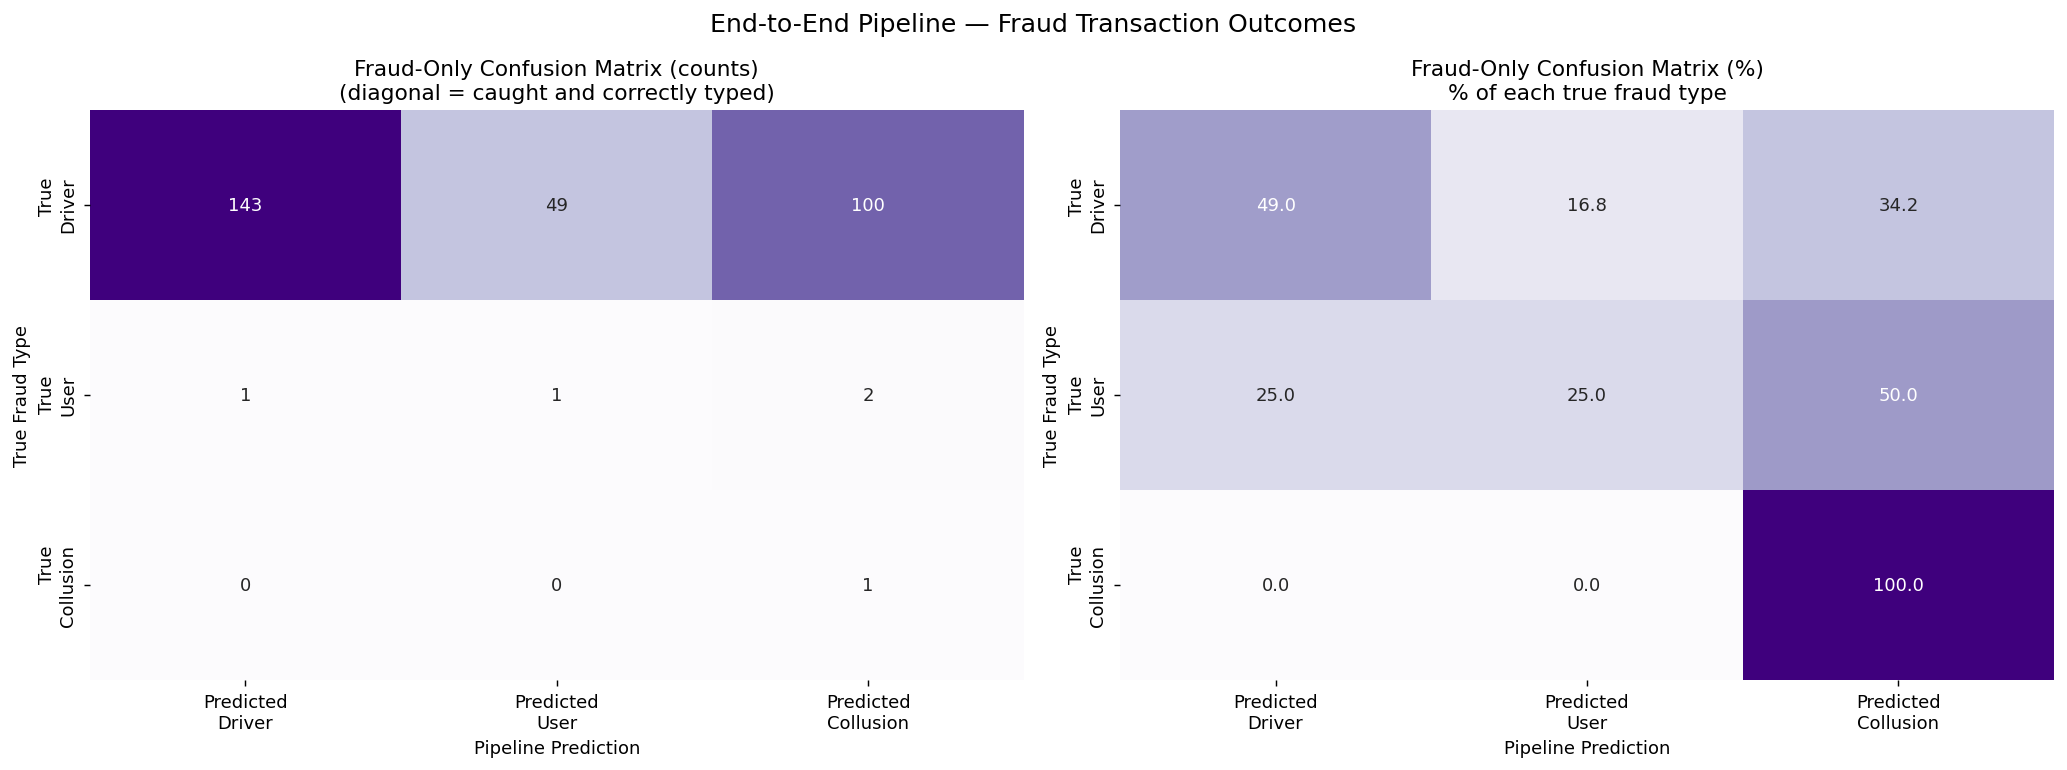

In [26]:
# Full 4-class confusion matrix
# Classes: 0=Legitimate released, 1=Driver caught,
#           2=User caught, 3=Collusion caught
# Misses: fraud that escaped Stage 1 shows as 0 prediction
#          on true class 1/2/3

# Get true fraud type for all test transactions
# For non-fraud, true_fraud_type = 0
pipeline_df_full = pipeline_df.copy()

# True full labels (0=legit, 1/2/3=fraud type)
true_full_labels = []
for idx, row in pipeline_df_full.iterrows():
    orig_idx = row["original_idx"]
    if row["true_label"] == 0:
        true_full_labels.append(0)
    else:
        # Find the fraud type from Stage 2 training data
        # Use modeling_s2 index alignment
        try:
            fraud_type = modeling_s2[
                modeling_s2.index == orig_idx
            ]["fraud_label"].values
            if len(fraud_type) > 0:
                true_full_labels.append(int(fraud_type[0]))
            else:
                true_full_labels.append(1)  # default driver fraud
        except:
            true_full_labels.append(1)

pipeline_df_full["true_full_label"] = true_full_labels

# Predicted full labels
# Released by Stage 1 → predict 0 (legitimate)
# Flagged by Stage 1 → use Stage 2 prediction
pred_full_labels = []
for idx, row in pipeline_df_full.iterrows():
    if row["s1_prediction"] == 0:
        pred_full_labels.append(0)  # predicted legitimate
    else:
        pred_full_labels.append(int(row["s2_fraud_type"]))

pipeline_df_full["pred_full_label"] = pred_full_labels

# Confusion matrix — only on fraud rows
fraud_rows = pipeline_df_full[
    pipeline_df_full["true_full_label"] != 0
]

# Build confusion: rows=true class, cols=predicted
# Predicted 0 = fraud escaped Stage 1
cm_labels = [0, 1, 2, 3]
cm_names  = ["Escaped\n(Missed)", "Driver\nFraud",
             "User\nFraud", "Collusion\nFraud"]

from sklearn.metrics import confusion_matrix as sklearn_cm
cm = sklearn_cm(
    fraud_rows["true_full_label"],
    fraud_rows["pred_full_label"],
    labels=[1,2,3]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("End-to-End Pipeline — Fraud Transaction Outcomes",
             fontsize=14)

# Counts
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Purples",
    xticklabels=["Predicted\nDriver","Predicted\nUser","Predicted\nCollusion"],
    yticklabels=["True\nDriver","True\nUser","True\nCollusion"],
    ax=axes[0], cbar=False
)
axes[0].set_title("Fraud-Only Confusion Matrix (counts)\n"
                  "(diagonal = caught and correctly typed)")
axes[0].set_xlabel("Pipeline Prediction")
axes[0].set_ylabel("True Fraud Type")

# Percentages
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(
    cm_pct, annot=True, fmt=".1f", cmap="Purples",
    xticklabels=["Predicted\nDriver","Predicted\nUser","Predicted\nCollusion"],
    yticklabels=["True\nDriver","True\nUser","True\nCollusion"],
    ax=axes[1], cbar=False
)
axes[1].set_title("Fraud-Only Confusion Matrix (%)\n"
                  "% of each true fraud type")
axes[1].set_xlabel("Pipeline Prediction")
axes[1].set_ylabel("True Fraud Type")

plt.tight_layout()
plt.savefig("../data/processed/eval_05_full_pipeline_cm.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [27]:
summary = {
    "stage1_model"           : "LightGBM",
    "stage1_threshold"       : OPTIMAL_THRESHOLD_S1,
    "stage1_avg_precision"   : float(s1_ap),
    "stage1_recall"          : float(recall_score(y_test_s1, s1_pred)),
    "stage1_precision"       : float(precision_score(y_test_s1, s1_pred)),
    "stage2_model"           : "Logistic Regression",
    "stage2_macro_f1"        : 1.0000,
    "pipeline_fraud_caught_pct": float(tp / fraud_total * 100),
    "pipeline_false_alarm_pct" : float(fp / (fp + tn) * 100),
    "total_test_transactions"  : int(total),
    "total_fraud_in_test"      : int(fraud_total),
    "fraud_caught"             : int(tp),
    "fraud_escaped"            : int(fn),
    "false_alarms"             : int(fp),
}

import json
with open(PATH + "pipeline_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Pipeline summary saved")
print(json.dumps(summary, indent=2))

✅ Pipeline summary saved
{
  "stage1_model": "LightGBM",
  "stage1_threshold": 0.6994,
  "stage1_avg_precision": 0.8794893389214505,
  "stage1_recall": 0.8114754098360656,
  "stage1_precision": 0.8892215568862275,
  "stage2_model": "Logistic Regression",
  "stage2_macro_f1": 1.0,
  "pipeline_fraud_caught_pct": 81.14754098360656,
  "pipeline_false_alarm_pct": 0.31803335052432524,
  "total_test_transactions": 12000,
  "total_fraud_in_test": 366,
  "fraud_caught": 297,
  "fraud_escaped": 69,
  "false_alarms": 37
}
